# Ustvarjanje PlanetScope naročnine v eno kolekcijo

V tem zvezku pripravimo **Planet Subscription**, ki:

- zajame **arhivske podatke** od izbranega datuma naprej,
- lahko nadaljuje z dodajanjem **novih posnetkov** v prihodnje,
- vse rezultate zapisuje v **eno gostovano kolekcijo**,
- obdelavo pusti za kasneje, zato se naročnina osredotoča le na zajem in gostovanje.

## Zahteve

- nameščen Python
- knjižnice `requests`, `matplotlib`, `shapely`, po želji tudi `contextily`
- [Planet Account](https://www.planet.com/account/#/)
- API ključ za dostop do Planet API
- GeoJSON datoteka z območjem interesa (**AOI**)


In [1]:
# Potrebne knjižnice
import os
import json
import time
import requests
from typing import Dict, Optional

import matplotlib.pyplot as plt
from shapely.geometry import shape
from requests.auth import HTTPBasicAuth
# contextily je uporaben za ozadje zemljevida, ni pa obvezen
try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except Exception:
    HAS_CONTEXTILY = False

## Nastavitev API ključa

API ključ lahko preberemo iz spremenljivke okolja `PL_API_KEY` ali pa ga prilepimo neposredno v zvezek.


In [2]:
# Če je API ključ nastavljen kot spremenljivka okolja, ga uporabimo
if os.environ.get("PL_API_KEY", ""):
    API_KEY = os.environ.get("PL_API_KEY", "")
else:
    API_KEY = "PASTE_YOUR_API_KEY_HERE"  # po potrebi zamenjaj

In [3]:
# Kratek preveritveni izpis
if API_KEY and API_KEY != "PASTE_YOUR_API_KEY_HERE":
    print(f"API ključ naložen: {API_KEY[:4]}...{API_KEY[-4:]}")
else:
    print("API ključ še ni nastavljen.")

API ključ naložen: PLAK...fdbd


## Določitev območja interesa

Območje interesa (**AOI**) določimo z GeoJSON datoteko. Iz nje preberemo geometrijo, ki jo uporabimo v zahtevi za Subscription API.


In [4]:
# Ime datoteke z AOI
aoi_file = "./podatki/kranj_okolica_aoi.geojson"

with open(aoi_file, encoding="utf-8") as f:
    geojson_data = json.load(f)

# Podpiramo tako FeatureCollection kot tudi neposredno geometrijo
if geojson_data.get("type") == "FeatureCollection":
    geojson_geometry = geojson_data["features"][0]["geometry"]
elif geojson_data.get("type") == "Feature":
    geojson_geometry = geojson_data["geometry"]
else:
    geojson_geometry = geojson_data

In [5]:
# Izpis geometrije AOI za preverjanje
print(json.dumps(geojson_geometry, indent=2, ensure_ascii=False)[:3000])

{
  "coordinates": [
    [
      [
        14.289101387585958,
        46.200560325817435
      ],
      [
        14.464087948922668,
        46.200560325817435
      ],
      [
        14.464087948922668,
        46.31230158968515
      ],
      [
        14.289101387585958,
        46.31230158968515
      ],
      [
        14.289101387585958,
        46.200560325817435
      ]
    ]
  ],
  "type": "Polygon"
}


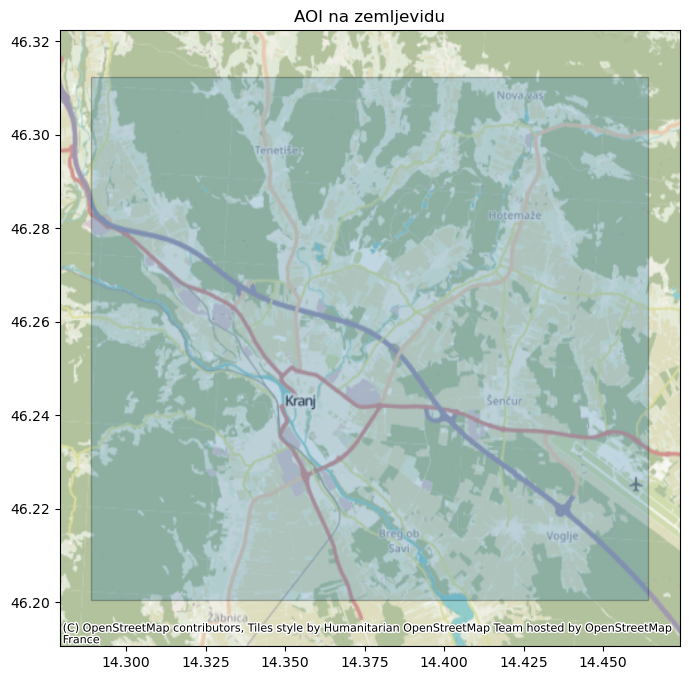

In [6]:
# Prikaz AOI na zemljevidu
aoi_shape = shape(geojson_geometry)
minx, miny, maxx, maxy = aoi_shape.bounds

fig, ax = plt.subplots(figsize=(8, 8))

if aoi_shape.geom_type == "Polygon":
    x, y = aoi_shape.exterior.xy
    ax.fill(x, y, alpha=0.25, ec="black")
else:
    for geom in aoi_shape.geoms:
        x, y = geom.exterior.xy
        ax.fill(x, y, alpha=0.25, ec="black")

ax.set_xlim(minx - 0.01, maxx + 0.01)
ax.set_ylim(miny - 0.01, maxy + 0.01)

if HAS_CONTEXTILY:
    try:
        ctx.add_basemap(ax, crs="EPSG:4326")
    except Exception as e:
        print(f"Ozadja zemljevida ni bilo mogoče dodati: {e}")

ax.set_title("AOI na zemljevidu")
plt.show()

## Nastavitve

Tukaj nastavimo osnovne parametre naročnine:
- ime naročnine,
- časovni razpon za arhivske podatke,
- tip podatkov in produkt,
- obstoječi `collection_id`, če želimo dodajati v že ustvarjeno kolekcijo.


In [7]:
# Osnovne nastavitve naročnine
SUBSCRIPTION_NAME = "Kranj"

ITEM_TYPES = ["PSScene"]
ASSET_TYPES = ["ortho_analytic_8b_sr"]

# Arhivski začetek; če END_TIME pustiš na None, bo naročnina tekla tudi v prihodnje
START_TIME = "2022-01-01T00:00:00Z"
END_TIME = None  # npr. "2024-12-31T23:59:59Z" za samo arhiv

# Če želiš uporabiti obstoječo kolekcijo, vpiši njen ID.
# Če pustiš None, Planet pri prvi naročnini ustvari novo kompatibilno kolekcijo.
TARGET_COLLECTION_ID = None

# Naročnina je namenjena zajemu v eno kolekcijo brez dodatne obdelave
TOOLS = []

In [8]:
# API endpointi
SUBSCRIPTIONS_URL = "https://api.planet.com/subscriptions/v1/subscriptions" 

### API povezava in avtentikacija

Inicializiramo HTTP sejo, da bodo vsi klici uporabljali isti API ključ.


In [9]:
# Inicializacija HTTP seje
SESSION = requests.Session()
SESSION.auth = HTTPBasicAuth(API_KEY, "")
SESSION.headers.update({"Accept": "application/json", "Content-Type": "application/json"})

## Pomožne funkcije

Funkcije spodaj:
- sestavijo payload za naročnino,
- pošljejo zahtevo za ustvarjanje,
- po potrebi preberejo stanje naročnine,
- poiščejo `collection_id` v odzivu.


In [10]:
def build_subscription_payload(
    name: str,
    geometry: Dict,
    start_time: str,
    end_time: Optional[str] = None,
    collection_id: Optional[str] = None,
    item_types=None,
    asset_types=None,
    tools=None,
) -> Dict:
    if item_types is None:
        item_types = ["PSScene"]
    if asset_types is None:
        asset_types = ["ortho_analytic_4b"]
    if tools is None:
        tools = []

    payload = {
        "name": name,
        "source": {
            "type": "catalog",
            "parameters": {
                "item_types": item_types,
                "asset_types": asset_types,
                "start_time": start_time,
                "time_range_type": "acquired",
                "geometry": geometry,
                "geometry_relation": "intersects",
            },
        },
        "hosting": {
            "type": "sentinel_hub",
        },
    }

    if end_time:
        payload["source"]["parameters"]["end_time"] = end_time

    if collection_id:
        payload["hosting"]["parameters"] = {"collection_id": collection_id}

    if tools:
        payload["tools"] = tools

    return payload


def create_subscription(payload: Dict) -> Dict:
    response = SESSION.post(SUBSCRIPTIONS_URL, json=payload, timeout=120)
    try:
        data = response.json()
    except ValueError:
        response.raise_for_status()
        raise RuntimeError(f"Nepričakovan ne-JSON odziv: {response.text[:500]}")
    response.raise_for_status()
    return data


def get_subscription(subscription_id: str) -> Dict:
    response = SESSION.get(f"{SUBSCRIPTIONS_URL}/{subscription_id}", timeout=120)
    try:
        data = response.json()
    except ValueError:
        response.raise_for_status()
        raise RuntimeError(f"Nepričakovan ne-JSON odziv: {response.text[:500]}")
    response.raise_for_status()
    return data


def deep_get_collection_id(obj):
    if isinstance(obj, dict):
        hosting = obj.get("hosting")
        if isinstance(hosting, dict):
            params = hosting.get("parameters", {})
            if isinstance(params, dict) and params.get("collection_id"):
                return params["collection_id"]
        for value in obj.values():
            found = deep_get_collection_id(value)
            if found:
                return found
    elif isinstance(obj, list):
        for value in obj:
            found = deep_get_collection_id(value)
            if found:
                return found
    return None


def poll_subscription(subscription_id: str, attempts: int = 12, sleep_s: int = 10) -> Dict:
    last = None
    for i in range(attempts):
        last = get_subscription(subscription_id)
        status = last.get("status")
        collection_id = deep_get_collection_id(last)
        backfill_complete = last.get("backfill_complete")
        print(
            f"[{i+1}/{attempts}] status={status} | "
            f"collection_id={collection_id} | backfill_complete={backfill_complete}"
        )
        if status in {"running", "active", "completed"}:
            return last
        time.sleep(sleep_s)
    return last

## Priprava payloada

V tej sekciji sestavimo zahtevo za naročnino, ki bo podatke zapisovala v eno kolekcijo.


In [11]:
payload = build_subscription_payload(
    name=SUBSCRIPTION_NAME,
    geometry=geojson_geometry,
    start_time=START_TIME,
    end_time=END_TIME,
    collection_id=TARGET_COLLECTION_ID,
    item_types=ITEM_TYPES,
    asset_types=ASSET_TYPES,
    tools=TOOLS,
)

print(json.dumps(payload, indent=2, ensure_ascii=False))

{
  "name": "Kranj",
  "source": {
    "type": "catalog",
    "parameters": {
      "item_types": [
        "PSScene"
      ],
      "asset_types": [
        "ortho_analytic_8b_sr"
      ],
      "start_time": "2022-01-01T00:00:00Z",
      "time_range_type": "acquired",
      "geometry": {
        "coordinates": [
          [
            [
              14.289101387585958,
              46.200560325817435
            ],
            [
              14.464087948922668,
              46.200560325817435
            ],
            [
              14.464087948922668,
              46.31230158968515
            ],
            [
              14.289101387585958,
              46.31230158968515
            ],
            [
              14.289101387585958,
              46.200560325817435
            ]
          ]
        ],
        "type": "Polygon"
      },
      "geometry_relation": "intersects"
    }
  },
  "hosting": {
    "type": "sentinel_hub"
  }
}


## Povzetek nastavitev

Pred pošiljanjem zahteve izpišemo najpomembnejše parametre.


In [12]:
print("\nPovzetek naročnine:")
print(f"- Ime naročnine: {SUBSCRIPTION_NAME}")
print(f"- Tip posnetkov: {ITEM_TYPES}")
print(f"- Produkt / asset type: {ASSET_TYPES}")
print(f"- Začetek arhiva: {START_TIME}")
print(f"- Konec časovnega intervala: {END_TIME}")
print(f"- Ciljni ID kolekcije: {TARGET_COLLECTION_ID}")
print(f"- Število orodij za obdelavo: {len(TOOLS)}")
print(f"- AOI datoteka: {aoi_file}")
print(f"- Tip geometrije AOI: {geojson_geometry['type']}")


Povzetek naročnine:
- Ime naročnine: Kranj
- Tip posnetkov: ['PSScene']
- Produkt / asset type: ['ortho_analytic_8b_sr']
- Začetek arhiva: 2022-01-01T00:00:00Z
- Konec časovnega intervala: None
- Ciljni ID kolekcije: None
- Število orodij za obdelavo: 0
- AOI datoteka: ./podatki/kranj_okolica_aoi.geojson
- Tip geometrije AOI: Polygon


In [13]:
# Opozorilo: naslednji korak ustvari novo naročnino v vašem Planet računu
print("\nOPOZORILO: Naslednji korak bo ustvaril Planet Subscription, kar lahko povzroči stroške glede na vaš paket in količino podatkov.")
odgovor = input("Ali želite nadaljevati z ustvarjanjem naročnine? (da/ne): ").strip().lower()

if odgovor not in ("da", "yes"):
    print("Ustvarjanje naročnine je preklical uporabnik.")
    proceed = False
else:
    proceed = True
    print("Ustvarjanje naročnine se nadaljuje.")


OPOZORILO: Naslednji korak bo ustvaril Planet Subscription, kar lahko povzroči stroške glede na vaš paket in količino podatkov.
Ustvarjanje naročnine je preklical uporabnik.


## Ustvarjanje naročnine

Če je `TARGET_COLLECTION_ID = None`, Planet pri prvem uspešnem ustvarjanju običajno vrne novo kompatibilno kolekcijo.  
Če uporabiš obstoječ `collection_id`, bodo rezultati zapisani v to kolekcijo.


In [14]:
created = None
subscription_id = None
collection_id = None

if proceed:
    created = create_subscription(payload)
    subscription_id = created.get("id")
    collection_id = deep_get_collection_id(created)

    print("\nOdziv API:")
    print(json.dumps(created, indent=2, ensure_ascii=False)[:5000])

    print("\nOsnovni rezultat:")
    print(f"- subscription_id: {subscription_id}")
    print(f"- collection_id: {collection_id}")

## Spremljanje stanja

V nekaj korakih preverimo, ali je naročnina sprejeta in ali je `collection_id` že viden tudi v podrobnem odzivu.


In [15]:
latest = None

if proceed and subscription_id:
    latest = poll_subscription(subscription_id, attempts=12, sleep_s=10)

    print("\nZadnji znani odziv:")
    print(json.dumps(latest, indent=2, ensure_ascii=False)[:5000])

## Ponovna uporaba iste kolekcije

Ko enkrat dobiš `collection_id`, ga lahko shraniš in uporabiš pri naslednjih naročninah istega tipa podatkov.


In [16]:
REUSED_COLLECTION_ID = collection_id or "paste-existing-collection-id-here"

next_payload = build_subscription_payload(
    name=f"{SUBSCRIPTION_NAME}-druga",
    geometry=geojson_geometry,
    start_time=START_TIME,
    end_time=END_TIME,
    collection_id=REUSED_COLLECTION_ID,
    item_types=ITEM_TYPES,
    asset_types=ASSET_TYPES,
    tools=TOOLS,
)

print(json.dumps(next_payload, indent=2, ensure_ascii=False))

{
  "name": "Kranj-druga",
  "source": {
    "type": "catalog",
    "parameters": {
      "item_types": [
        "PSScene"
      ],
      "asset_types": [
        "ortho_analytic_8b_sr"
      ],
      "start_time": "2022-01-01T00:00:00Z",
      "time_range_type": "acquired",
      "geometry": {
        "coordinates": [
          [
            [
              14.289101387585958,
              46.200560325817435
            ],
            [
              14.464087948922668,
              46.200560325817435
            ],
            [
              14.464087948922668,
              46.31230158968515
            ],
            [
              14.289101387585958,
              46.31230158968515
            ],
            [
              14.289101387585958,
              46.200560325817435
            ]
          ]
        ],
        "type": "Polygon"
      },
      "geometry_relation": "intersects"
    }
  },
  "hosting": {
    "type": "sentinel_hub",
    "parameters": {
      "collection

## Povzetek rezultatov

Na koncu izpišemo najpomembnejše informacije o ustvarjeni naročnini.


In [17]:
print("\nKončano.")
if created:
    print(f"- ID naročnine: {subscription_id}")
    print(f"- Ime naročnine: {created.get('name')}")
    print(f"- Status: {created.get('status')}")
    print(f"- Kolekcija: {collection_id}")
else:
    print("Naročnina ni bila ustvarjena.")


Končano.
Naročnina ni bila ustvarjena.


## Opombe

- Če želiš samo arhivski izrez, nastavi tudi `END_TIME`.
- Če želiš arhiv + prihodnje posnetke, pusti `END_TIME = None`.
- Če želiš obdelavo izvesti kasneje, pusti `TOOLS = []`.
- Če prvič ustvarjaš kolekcijo, začni z `TARGET_COLLECTION_ID = None`.
- Za spremljanje vseh naročnin lahko uporabiš ločen monitor notebook.
